# Evaluate Performance

This document evaluates the performance (planning time and running time) of different methods (DuckDB, StarCE, SafeBound, FactorJoin) across benchmarks.

## Module 1: Performance Testing

Testing performance of the following methods:
- **DuckDB**: using DuckDBTestRunner
- **StarCE**: using StarCETestRunner
- **SafeBound**: using InjectionTestRunner (injected method)
- **FactorJoin**: using InjectionTestRunner (injected method)
- **BayesCard**: using InjectionTestRunner (injected method)
- **TrueCard**: using InjectionTestRunner to inject true subquery cardinalities, as a reference method


In [1]:
# ========== Imports and Configuration ==========
import sys
import os
import csv
from pathlib import Path
from typing import Dict, Optional

# Add ExperimentRunner to path
sys.path.insert(0, str(Path.cwd()))
from ExperimentRunner import (
    DuckDBTestRunner,
    StarCETestRunner,
    InjectionTestRunner,
    setup_starce_executable
)

# Auto-detect project root directory
def get_project_root():
    """GetProject root directory"""
    cwd = Path.cwd()
    for parent in [cwd] + list(cwd.parents):
        if (parent / "Benchmark").exists() and (parent / "experiment").exists():
            return parent
    if "experiment" in str(cwd):
        return cwd.parent
    return cwd

PROJECT_ROOT = get_project_root()
print(f"Project root directory: {PROJECT_ROOT}")

SAFEBOUND_CHECKPOINT = PROJECT_ROOT / "experiment" / "checkpoint" / "SafeBound"
FACTORJOIN_CHECKPOINT = PROJECT_ROOT / "experiment" / "checkpoint" / "FactorJoin"
BAYESCARD_CHECKPOINT = PROJECT_ROOT / "experiment" / "checkpoint" / "BayesCard"

experiment_dir = PROJECT_ROOT / "experiment"
running_space = experiment_dir / "running_space"

Project root directory: /home/user/project/starce-final/StarCE


In [2]:
# ========== Helper Functions ==========

def read_csv_rows(csv_file: Path):
    if not csv_file.exists():
        raise FileNotFoundError(f"Missing results file: {csv_file}")

    with open(csv_file, 'r', encoding='utf-8') as f:
        return list(csv.DictReader(f))


def get_safebound_evaluation_time(benchmark: str) -> float:
    """
    Read evaluation time from SafeBound benchmark_times.csv
    """
    rows = read_csv_rows(SAFEBOUND_CHECKPOINT / "benchmark_times.csv")
    for row in rows:
        if row['Benchmark'] == benchmark:
            eval_time = row.get('EvaluationTime', '')
            if eval_time and eval_time.strip():
                return float(eval_time)
            raise ValueError(f"SafeBound Missing EvaluationTime: {benchmark}")
    raise ValueError(f"SafeBound benchmark_times.csv Missing benchmark: {benchmark}")


def get_safebound_card_path(benchmark: str) -> Path:
    """
    Get SafeBound cardinality file path
    """
    card_files = {
        'STATS': SAFEBOUND_CHECKPOINT / "SafeBound_3_Stats_evaluate_results.txt",
        'JOBM': SAFEBOUND_CHECKPOINT / "SafeBound_3_JOBM_evaluate_results.txt",
        'JOBLight': SAFEBOUND_CHECKPOINT / "SafeBound_3_JOBLight_evaluate_results.txt",
        'JOBLightRanges': SAFEBOUND_CHECKPOINT / "SafeBound_3_JOBLightRanges_evaluate_results.txt",
    }
    card_file = card_files.get(benchmark)
    if card_file is None:
        raise ValueError(f"Unsupported SafeBound benchmark: {benchmark}")

    if not card_file.exists():
        raise FileNotFoundError(f"Missing SafeBound cardinality file: {card_file}")
    return card_file


def get_factorjoin_summary_row(benchmark: str) -> dict:
    """
    Read summary row for a benchmark from FactorJoin benchmark_times.csv
    """
    rows = read_csv_rows(FACTORJOIN_CHECKPOINT / "benchmark_times.csv")
    for row in rows:
        if row['benchmark'] == benchmark:
            return row
    raise ValueError(f"FactorJoin benchmark_times.csv Missing benchmark: {benchmark}")


def get_factorjoin_evaluation_time(benchmark: str) -> float:
    row = get_factorjoin_summary_row(benchmark)
    eval_time = row.get('total_eval_like_time_sec', '')
    if eval_time and eval_time.strip():
        return float(eval_time)
    raise ValueError(f"FactorJoin Missing total_eval_like_time_sec: {benchmark}")


def get_factorjoin_card_path(benchmark: str) -> Path:
    row = get_factorjoin_summary_row(benchmark)
    card_file = FACTORJOIN_CHECKPOINT / Path(row['checkpoint_output']).name
    if not card_file.exists():
        raise FileNotFoundError(f"Missing FactorJoin cardinality file: {card_file}")
    return card_file


def get_ceb_card_path(benchmark: str, method: str) -> Path:
    """
    Get cardinality file path for CEB external methods (flat/bayescard/deepdb/neurocard/lpbound)
    Only supports STATS and JOBLight
    """
    workload_map = {
        'STATS': 'STATS-CEB',
        'JOBLight': 'JOBLight',
    }
    workload = workload_map.get(benchmark)
    if workload is None:
        raise ValueError(f"CEB methods only supports STATS/JOBLight, got: {benchmark}")
    card_file = PROJECT_ROOT / "Benchmark" / "workloads" / workload / "subquery" / "result" / f"{method}.txt"
    if not card_file.exists():
        raise FileNotFoundError(f"Missing CEB/{method} cardinality file: {card_file}")
    return card_file


def get_true_card_path(benchmark: str) -> Path:
    benchmark_dirs = {
        'STATS': PROJECT_ROOT / "Benchmark" / "workloads" / "STATS-CEB",
        'JOBM': PROJECT_ROOT / "Benchmark" / "workloads" / "JOBM",
        'JOBLight': PROJECT_ROOT / "Benchmark" / "workloads" / "JOBLight",
        'JOBLightRanges': PROJECT_ROOT / "Benchmark" / "workloads" / "JOBLightRanges",
    }
    benchmark_dir = benchmark_dirs.get(benchmark)
    if benchmark_dir is None:
        raise ValueError(f"Unsupported true-card benchmark: {benchmark}")

    card_file = benchmark_dir / "subquery" / "result" / "real.txt"
    if not card_file.exists():
        raise FileNotFoundError(f"Missing true-card cardinality file: {card_file}")
    return card_file


def get_bayescard_evaluation_time(benchmark: str) -> float:
    """
    Read evaluation time from BayesCard benchmark_times.csv
    """
    rows = read_csv_rows(BAYESCARD_CHECKPOINT / "benchmark_times.csv")
    # CSV has two STATS records (STATS-CEB and STATS), prefer the one with model_dir (pure BN path)
    candidates = [r for r in rows if r['benchmark'] == benchmark or (benchmark == 'STATS' and r['benchmark'] in ('STATS', 'STATS-CEB'))]
    # Pick the one with the largest eval time (pure BN path is usually longer), or the one with model_dir
    for r in candidates:
        if r.get('model_dir', '').strip():
            return float(r['total_eval_like_time_sec'])
    if candidates:
        return float(candidates[-1]['total_eval_like_time_sec'])
    raise ValueError(f"BayesCard MissingEvaluation time: {benchmark}")


LPBOUND_CHECKPOINT = PROJECT_ROOT / "experiment" / "checkpoint" / "LpBound"

def get_lpbound_evaluation_time(benchmark: str) -> float:
    """
    Read estimate time from LpBound timing_details.json (parallel mode, sec/query)
    """
    import json
    mapping = {'STATS': 'stats', 'JOBLight': 'joblight', 'JOBM': 'jobjoin'}
    lpbound_bench = mapping.get(benchmark)
    if lpbound_bench is None:
        raise ValueError(f"LpBound does not support benchmark: {benchmark}")

    timing_file = LPBOUND_CHECKPOINT / "timing_details.json"
    if not timing_file.exists():
        raise FileNotFoundError(f"Missing LpBound timing file: {timing_file}")

    with open(timing_file) as f:
        data = json.load(f)

    est_data = data.get('estimate_time', {}).get(lpbound_bench, {})
    total_s = est_data.get('total_parallel_s')
    if total_s is None:
        raise ValueError(f"LpBound Missing {benchmark}  total_parallel_s")

    return float(total_s)


In [3]:
# ========== Load Checkpoint (initialize performance_results) ==========
import json

PERF_CHECKPOINT_DIR = PROJECT_ROOT / "experiment" / "checkpoint" / "EvaluatePerformance"
PERF_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PERF_CHECKPOINT_FILE = PERF_CHECKPOINT_DIR / "performance_results.json"

ALL_METHODS = ['DuckDB', 'StarCE', 'SafeBound', 'FactorJoin', 'BayesCard', 'Flat', 'LpBound', 'DeepDB', 'NeuroCard', 'TrueCard']

if PERF_CHECKPOINT_FILE.exists():
    with open(PERF_CHECKPOINT_FILE, 'r', encoding='utf-8') as f:
        performance_results = json.load(f)
    # Ensure all methods have initialization entries (compatible with old checkpoints)
    for m in ALL_METHODS:
        if m not in performance_results:
            performance_results[m] = {}
    print(f"Loaded from checkpoint: {PERF_CHECKPOINT_FILE}")
    for method in ALL_METHODS:
        benchmarks_done = list(performance_results.get(method, {}).keys())
        print(f"  {method}: {benchmarks_done if benchmarks_done else '(no data)'}")
else:
    performance_results = {m: {} for m in ALL_METHODS}
    print("Checkpoint does not exist,initialized empty structure.")


def save_checkpoint():
    with open(PERF_CHECKPOINT_FILE, 'w', encoding='utf-8') as f:
        json.dump(performance_results, f, indent=2, ensure_ascii=False)
    print(f"Checkpoint updated: {PERF_CHECKPOINT_FILE}")


NUM_RUNS = 3  # Number of runs per test
ACTIVE_BENCHMARKS = ['STATS', 'JOBM', 'JOBLight', 'JOBLightRanges']


Loaded from checkpoint: /home/user/project/starce-final/StarCE/experiment/checkpoint/EvaluatePerformance/performance_results.json
  DuckDB: ['STATS', 'JOBM', 'JOBLight', 'JOBLightRanges']
  StarCE: ['STATS', 'JOBM', 'JOBLight', 'JOBLightRanges']
  SafeBound: ['STATS', 'JOBM', 'JOBLight', 'JOBLightRanges']
  FactorJoin: ['STATS', 'JOBM', 'JOBLight', 'JOBLightRanges']
  BayesCard: ['STATS', 'JOBLight']
  Flat: ['STATS', 'JOBLight']
  LpBound: ['STATS', 'JOBLight']
  DeepDB: ['STATS', 'JOBLight']
  NeuroCard: ['STATS', 'JOBLight']
  TrueCard: ['STATS', 'JOBM', 'JOBLight', 'JOBLightRanges']


In [4]:
# ========== Test DuckDB ==========
duckdb_runner = DuckDBTestRunner(str(PROJECT_ROOT))

duckdb_planning = duckdb_runner.test_planning_time(num_runs=NUM_RUNS, benchmarks=ACTIVE_BENCHMARKS)
duckdb_running  = duckdb_runner.test_running_time(num_runs=NUM_RUNS, benchmarks=ACTIVE_BENCHMARKS)

for benchmark in ACTIVE_BENCHMARKS:
    performance_results['DuckDB'][benchmark] = {
        'planning_time': duckdb_planning.get(benchmark),
        'running_time':  duckdb_running.get(benchmark),
    }
    print(f"DuckDB {benchmark}: planning={duckdb_planning.get(benchmark)}, running={duckdb_running.get(benchmark)}")

save_checkpoint()



=== Test planning time - DuckDB ===

--- Test planning time (STATS) ---
[2026-07-28 00:17:13] Starting planning time test (STATS), run(s) 3
[2026-07-28 00:17:13] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/input.sql  and added EXPLAIN
[2026-07-28 00:17:13] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 00:17:13] Using input.sql: run  1/3 run(s)...
[2026-07-28 00:17:13] starce ran successfully, elapsed: 0.17  seconds
[2026-07-28 00:17:13] Using input.sql: run  2/3 run(s)...
[2026-07-28 00:17:13] starce ran successfully, elapsed: 0.16  seconds
[2026-07-28 00:17:13] Using input.sql: run  3/3 run(s)...
[2026-07-28 00:17:13] starce ran successfully, elapsed: 0.16  seconds
[2026-07-28 00:17:13] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 00:17:13] using dummy_query.sql:  1/3 run(s)...
[2026-07-28 00:17:13] starce ran succ

In [5]:
# ========== Test StarCE ==========
starce_runner = StarCETestRunner(str(PROJECT_ROOT))

starce_planning = starce_runner.test_planning_time(num_runs=NUM_RUNS, benchmarks=ACTIVE_BENCHMARKS)
starce_running  = starce_runner.test_running_time(num_runs=NUM_RUNS, benchmarks=ACTIVE_BENCHMARKS)

for benchmark in ACTIVE_BENCHMARKS:
    performance_results['StarCE'][benchmark] = {
        'planning_time': starce_planning.get(benchmark),
        'running_time':  starce_running.get(benchmark),
    }
    print(f"StarCE {benchmark}: planning={starce_planning.get(benchmark)}, running={starce_running.get(benchmark)}")

save_checkpoint()



=== Test planning time - StarCE ===

--- Test planning time (STATS) ---
[2026-07-28 01:12:19] Starting planning time test (STATS), run(s) 3
[2026-07-28 01:12:19] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/input.sql  and added EXPLAIN
[2026-07-28 01:12:19] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 01:12:19] Using input.sql: run  1/3 run(s)...
[2026-07-28 01:12:19] starce ran successfully, elapsed: 0.18  seconds
[2026-07-28 01:12:19] Using input.sql: run  2/3 run(s)...
[2026-07-28 01:12:19] starce ran successfully, elapsed: 0.18  seconds
[2026-07-28 01:12:19] Using input.sql: run  3/3 run(s)...
[2026-07-28 01:12:19] starce ran successfully, elapsed: 0.18  seconds
[2026-07-28 01:12:19] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 01:12:19] using dummy_query.sql:  1/3 run(s)...
[2026-07-28 01:12:19] starce ran succ

In [6]:
# ========== Injected Method Test Helpers ==========
injection_runner = InjectionTestRunner(str(PROJECT_ROOT))


def run_injected_method(method_name, benchmarks, card_path_getter, eval_time_getter):
    print(f"[{method_name}] Starting test...")
    for benchmark in benchmarks:
        card_path = card_path_getter(benchmark)
        card_est_time = eval_time_getter(benchmark)
        print(f"\n{method_name} {benchmark}:")
        print(f"  Injecting cardinality file: {card_path}")
        print(f"  Cardinality estimation time: {card_est_time:.6f} sec")

        planning = injection_runner.test_planning_time(
            benchmark, str(card_path),
            card_est_time=card_est_time,
            num_runs=NUM_RUNS,
        )
        running = injection_runner.test_running_time(
            benchmark, str(card_path),
            num_runs=NUM_RUNS,
        )
        performance_results[method_name][benchmark] = {
            'planning_time': planning,
            'running_time':  running,
        }
        print(f"{method_name} {benchmark}: planning={planning}, running={running}")

    save_checkpoint()


In [7]:
# ========== Test SafeBound ==========
run_injected_method(
    'SafeBound',
    ACTIVE_BENCHMARKS,
    lambda benchmark: get_safebound_card_path(benchmark),
    lambda benchmark: get_safebound_evaluation_time('Stats' if benchmark == 'STATS' else benchmark),
)


[SafeBound] Starting test...

SafeBound STATS:
  Injecting cardinality file: /home/user/project/starce-final/StarCE/experiment/checkpoint/SafeBound/SafeBound_3_Stats_evaluate_results.txt
  Cardinality estimation time: 2.252660 sec

=== Test planning time - injection-based method (STATS) ===
Injected cardinality file path: /home/user/project/starce-final/StarCE/experiment/checkpoint/SafeBound/SafeBound_3_Stats_evaluate_results.txt
Cardinality estimation time: 2.25 seconds

--- Test planning time(injected cardinality) (STATS) ---
[2026-07-28 01:46:58] Starting planning time test(injected cardinality) (STATS), run(s) 3
[2026-07-28 01:46:58] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/input.sql  and added EXPLAIN
[2026-07-28 01:46:58] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 01:46:58] Using input.sql (injected cardinality):  1/3 run(s)...
[2026-07-28 01:46:58] starce ran successf

In [8]:
# ========== Test FactorJoin ==========
run_injected_method(
    'FactorJoin',
    ACTIVE_BENCHMARKS,
    lambda benchmark: get_factorjoin_card_path(benchmark),
    lambda benchmark: get_factorjoin_evaluation_time(benchmark),
)


[FactorJoin] Starting test...

FactorJoin STATS:
  Injecting cardinality file: /home/user/project/starce-final/StarCE/experiment/checkpoint/FactorJoin/card_stats.txt
  Cardinality estimation time: 30.236334 sec

=== Test planning time - injection-based method (STATS) ===
Injected cardinality file path: /home/user/project/starce-final/StarCE/experiment/checkpoint/FactorJoin/card_stats.txt
Cardinality estimation time: 30.24 seconds

--- Test planning time(injected cardinality) (STATS) ---
[2026-07-28 02:24:01] Starting planning time test(injected cardinality) (STATS), run(s) 3
[2026-07-28 02:24:01] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/input.sql  and added EXPLAIN
[2026-07-28 02:24:01] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 02:24:01] Using input.sql (injected cardinality):  1/3 run(s)...
[2026-07-28 02:24:01] starce ran successfully, elapsed: 0.17  seconds
[2026-07-28 0

In [9]:
# ========== External Mapping Methods Common Config ==========
# Estimation files for these methods are pre-mapped under Benchmark/workloads/, card_est_time=0
CEB_BENCHMARKS = ['STATS', 'JOBLight']

In [10]:
# ========== Test BayesCard (CEB) ==========
run_injected_method(
    'BayesCard',
    CEB_BENCHMARKS,
    lambda benchmark: get_ceb_card_path(benchmark, 'bayescard'),
    lambda benchmark: get_bayescard_evaluation_time(benchmark),
)


[BayesCard] Starting test...

BayesCard STATS:
  Injecting cardinality file: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/bayescard.txt
  Cardinality estimation time: 37.352180 sec

=== Test planning time - injection-based method (STATS) ===
Injected cardinality file path: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/bayescard.txt
Cardinality estimation time: 37.35 seconds

--- Test planning time(injected cardinality) (STATS) ---
[2026-07-28 03:04:49] Starting planning time test(injected cardinality) (STATS), run(s) 3
[2026-07-28 03:04:49] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/input.sql  and added EXPLAIN
[2026-07-28 03:04:49] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 03:04:49] Using input.sql (injected cardinality):  1/3 run(s)...
[2026-07-28 03:04:49] starce ran successfully, elapsed: 0.17 

In [11]:
# ========== Test Flat ==========
run_injected_method(
    'Flat',
    CEB_BENCHMARKS,
    lambda benchmark: get_ceb_card_path(benchmark, 'flat'),
    lambda benchmark: 0.0,
)


[Flat] Starting test...

Flat STATS:
  Injecting cardinality file: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/flat.txt
  Cardinality estimation time: 0.000000 sec

=== Test planning time - injection-based method (STATS) ===
Injected cardinality file path: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/flat.txt
Cardinality estimation time: 0.00 seconds

--- Test planning time(injected cardinality) (STATS) ---
[2026-07-28 03:13:26] Starting planning time test(injected cardinality) (STATS), run(s) 3
[2026-07-28 03:13:26] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/input.sql  and added EXPLAIN
[2026-07-28 03:13:26] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 03:13:26] Using input.sql (injected cardinality):  1/3 run(s)...
[2026-07-28 03:13:26] starce ran successfully, elapsed: 0.17  seconds
[2026-07-28 0

In [12]:
# ========== Test LpBound ==========
# LpBound cardinality files are mapped under Benchmark/workloads/
# Estimate time from LpBound C++ parallel mode (OMP_NUM_THREADS=8)
run_injected_method(
    'LpBound',
    CEB_BENCHMARKS,
    lambda benchmark: get_ceb_card_path(benchmark, 'lpbound'),
    lambda benchmark: get_lpbound_evaluation_time(benchmark),
)


[LpBound] Starting test...

LpBound STATS:
  Injecting cardinality file: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/lpbound.txt
  Cardinality estimation time: 0.174600 sec

=== Test planning time - injection-based method (STATS) ===
Injected cardinality file path: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/lpbound.txt
Cardinality estimation time: 0.17 seconds

--- Test planning time(injected cardinality) (STATS) ---
[2026-07-28 03:22:09] Starting planning time test(injected cardinality) (STATS), run(s) 3
[2026-07-28 03:22:09] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/input.sql  and added EXPLAIN
[2026-07-28 03:22:09] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 03:22:09] Using input.sql (injected cardinality):  1/3 run(s)...
[2026-07-28 03:22:09] starce ran successfully, elapsed: 0.19  seconds
[

In [13]:
# ========== Test DeepDB ==========
run_injected_method(
    'DeepDB',
    CEB_BENCHMARKS,
    lambda benchmark: get_ceb_card_path(benchmark, 'deepdb'),
    lambda benchmark: 0.0,
)


[DeepDB] Starting test...

DeepDB STATS:
  Injecting cardinality file: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/deepdb.txt
  Cardinality estimation time: 0.000000 sec

=== Test planning time - injection-based method (STATS) ===
Injected cardinality file path: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/deepdb.txt
Cardinality estimation time: 0.00 seconds

--- Test planning time(injected cardinality) (STATS) ---
[2026-07-28 03:31:15] Starting planning time test(injected cardinality) (STATS), run(s) 3
[2026-07-28 03:31:15] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/input.sql  and added EXPLAIN
[2026-07-28 03:31:15] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 03:31:15] Using input.sql (injected cardinality):  1/3 run(s)...
[2026-07-28 03:31:15] starce ran successfully, elapsed: 0.17  seconds
[2026

In [14]:
# ========== Test NeuroCard ==========
run_injected_method(
    'NeuroCard',
    CEB_BENCHMARKS,
    lambda benchmark: get_ceb_card_path(benchmark, 'neurocard'),
    lambda benchmark: 0.0,
)


[NeuroCard] Starting test...

NeuroCard STATS:
  Injecting cardinality file: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/neurocard.txt
  Cardinality estimation time: 0.000000 sec

=== Test planning time - injection-based method (STATS) ===
Injected cardinality file path: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/neurocard.txt
Cardinality estimation time: 0.00 seconds

--- Test planning time(injected cardinality) (STATS) ---
[2026-07-28 03:40:27] Starting planning time test(injected cardinality) (STATS), run(s) 3
[2026-07-28 03:40:27] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/input.sql  and added EXPLAIN
[2026-07-28 03:40:27] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 03:40:27] Using input.sql (injected cardinality):  1/3 run(s)...
[2026-07-28 03:40:28] starce ran successfully, elapsed: 0.17  s

In [15]:
# ========== Test TrueCard ==========
run_injected_method(
    'TrueCard',
    ACTIVE_BENCHMARKS,
    lambda benchmark: get_true_card_path(benchmark),
    lambda benchmark: 0.0,
)


[TrueCard] Starting test...

TrueCard STATS:
  Injecting cardinality file: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/real.txt
  Cardinality estimation time: 0.000000 sec

=== Test planning time - injection-based method (STATS) ===
Injected cardinality file path: /home/user/project/starce-final/StarCE/Benchmark/workloads/STATS-CEB/subquery/result/real.txt
Cardinality estimation time: 0.00 seconds

--- Test planning time(injected cardinality) (STATS) ---
[2026-07-28 03:49:07] Starting planning time test(injected cardinality) (STATS), run(s) 3
[2026-07-28 03:49:07] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/input.sql  and added EXPLAIN
[2026-07-28 03:49:07] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-28 03:49:07] Using input.sql (injected cardinality):  1/3 run(s)...
[2026-07-28 03:49:07] starce ran successfully, elapsed: 0.17  seconds
[2026

In [16]:
# ========== Performance Test Results Summary ==========
print("\n" + "=" * 80)
print("Performance test results summary:")
print("=" * 80)

for method in ALL_METHODS:
    print(f"\n{method}:")
    for benchmark in ACTIVE_BENCHMARKS:
        result = performance_results[method].get(benchmark, {})
        planning = result.get('planning_time')
        running  = result.get('running_time')
        p_str = f"{planning:.2f}" if planning is not None else "N/A"
        r_str = f"{running:.2f}"  if running  is not None else "N/A"
        print(f"  {benchmark}: planning={p_str}s, running={r_str}s")



Performance test results summary:

DuckDB:
  STATS: planning=0.14s, running=223.95s
  JOBM: planning=0.25s, running=42.46s
  JOBLight: planning=0.05s, running=60.57s
  JOBLightRanges: planning=0.74s, running=770.69s

StarCE:
  STATS: planning=0.16s, running=114.48s
  JOBM: planning=0.38s, running=37.07s
  JOBLight: planning=0.06s, running=54.75s
  JOBLightRanges: planning=0.80s, running=481.87s

SafeBound:
  STATS: planning=2.40s, running=126.58s
  JOBM: planning=66.13s, running=39.84s
  JOBLight: planning=0.38s, running=56.45s
  JOBLightRanges: planning=9.72s, running=513.47s

FactorJoin:
  STATS: planning=30.39s, running=119.20s
  JOBM: planning=104.14s, running=49.82s
  JOBLight: planning=1.88s, running=59.15s
  JOBLightRanges: planning=36.98s, running=583.05s

BayesCard:
  STATS: planning=37.50s, running=116.85s
  JOBM: planning=N/As, running=N/As
  JOBLight: planning=2.43s, running=54.80s
  JOBLightRanges: planning=N/As, running=N/As

Flat:
  STATS: planning=0.15s, running=120.71

## 2. Plotting Module

In [17]:
# ========== Reload Performance Data from Checkpoint ==========
import json
from pathlib import Path

def _get_project_root():
    cwd = Path.cwd()
    for parent in [cwd] + list(cwd.parents):
        if (parent / "Benchmark").exists() and (parent / "experiment").exists():
            return parent
    if "experiment" in str(cwd):
        return cwd.parent
    return cwd

_project_root = _get_project_root()
_perf_checkpoint_file = _project_root / "experiment" / "checkpoint" / "EvaluatePerformance" / "performance_results.json"

if not _perf_checkpoint_file.exists():
    raise FileNotFoundError(f"Checkpoint file does not exist: {_perf_checkpoint_file}")

with open(_perf_checkpoint_file, 'r', encoding='utf-8') as f:
    performance_results = json.load(f)

print(f"Loaded from checkpoint: {_perf_checkpoint_file}")


Loaded from checkpoint: /home/user/project/starce-final/StarCE/experiment/checkpoint/EvaluatePerformance/performance_results.json


PDF saved to: /home/user/project/starce-final/StarCE/experiment/checkpoint/EvaluatePerformance/performance_comparison.pdf


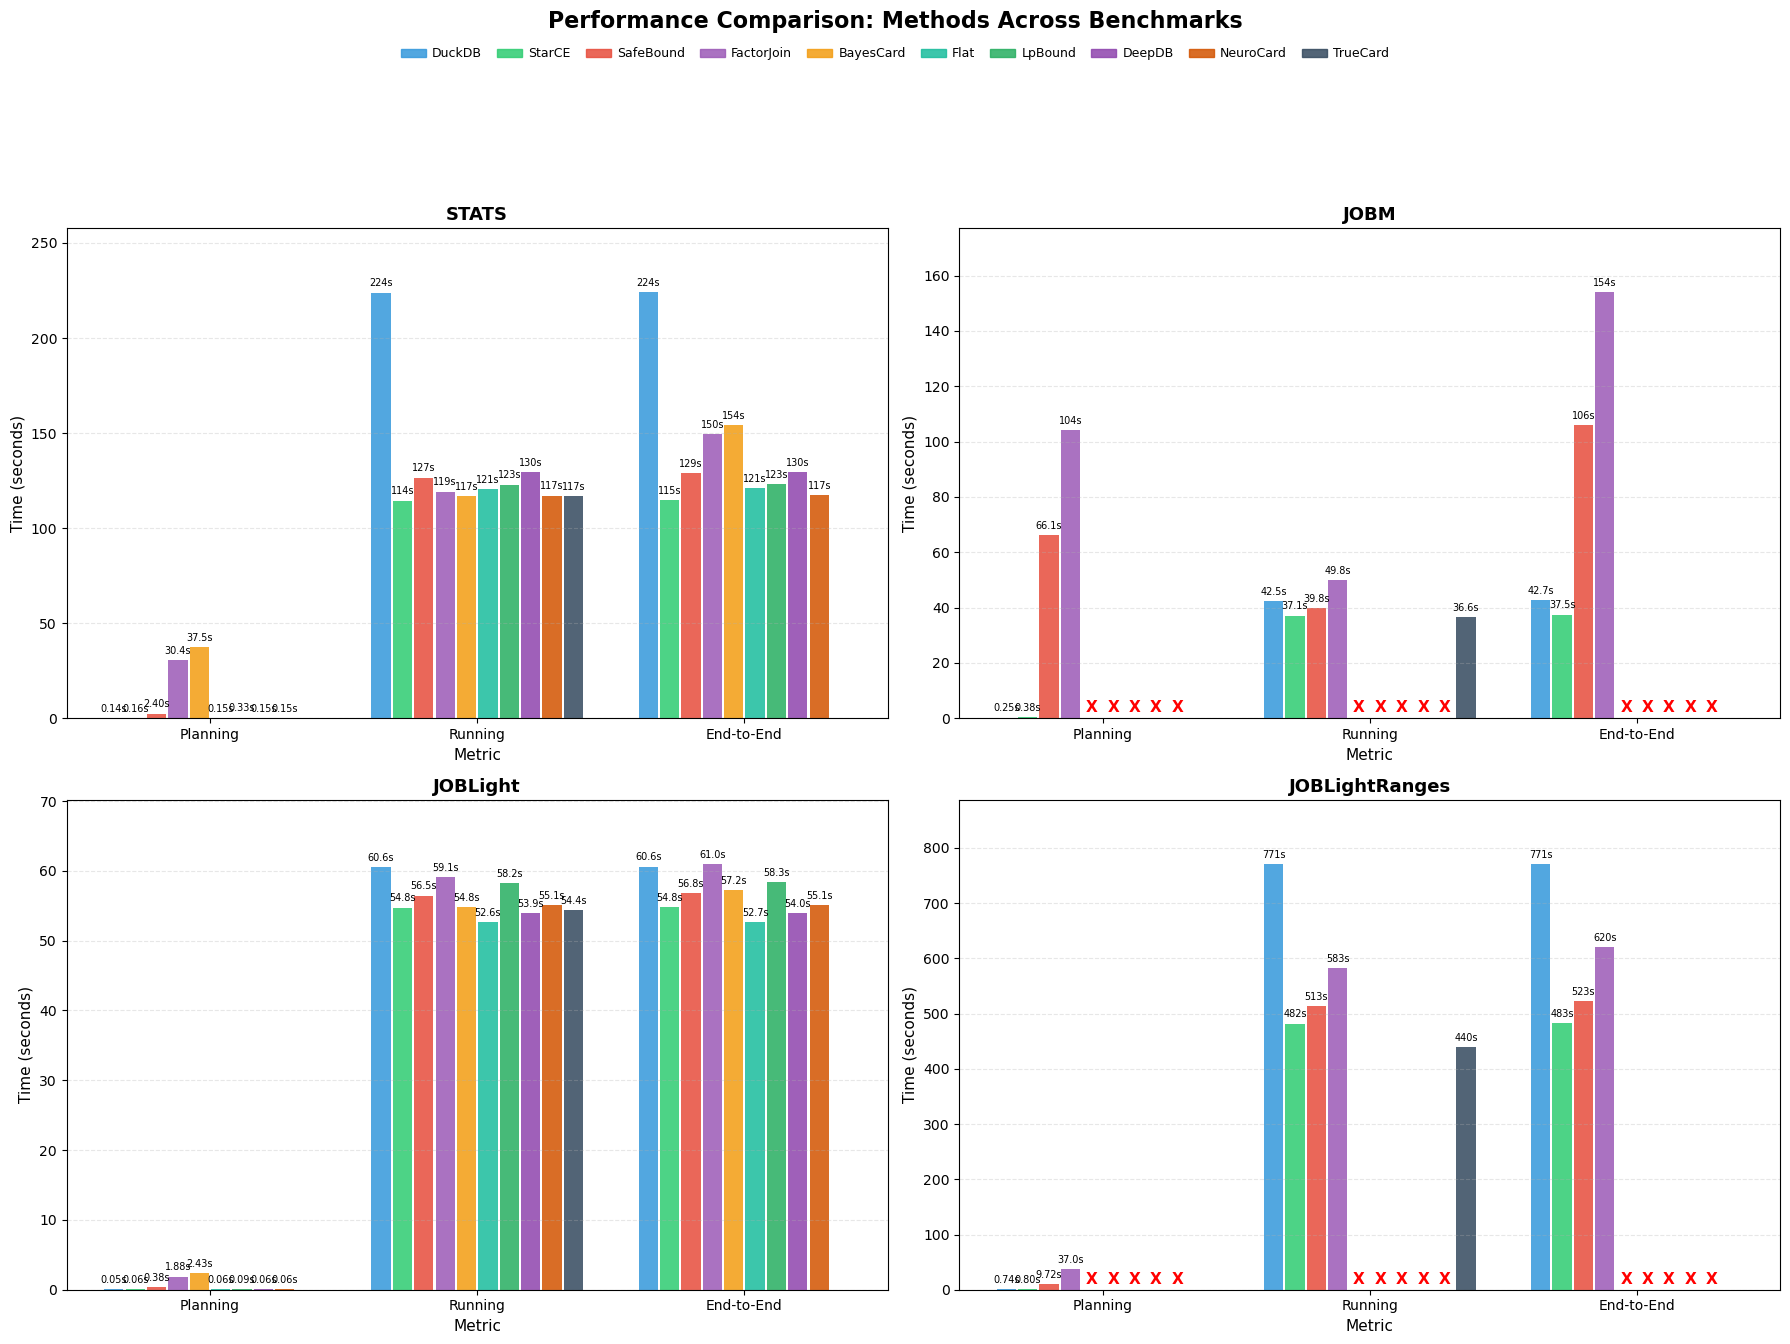

Performance comparison charts generated!


In [18]:
# ========== Plot: Performance Comparison Bar Charts ==========
# ========== Plotting Module: Performance Comparison Bar Charts ==========
import matplotlib.pyplot as plt
import numpy as np

# Select layout mode: '2x2' (default) or '1x4'
PLOT_LAYOUT = '2x2'

methods = ['DuckDB', 'StarCE', 'SafeBound', 'FactorJoin', 'BayesCard', 'Flat', 'LpBound', 'DeepDB', 'NeuroCard', 'TrueCard']
benchmarks = ['STATS', 'JOBM', 'JOBLight', 'JOBLightRanges']
metrics = [
    ('planning_time', 'Planning'),
    ('running_time',  'Running'),
    ('end_to_end',    'End-to-End'),
]

# (method, metric_name) combinations not plotted -- silently skipped, no X mark
HIDDEN_METRICS = {
    ('TrueCard', 'planning_time'),
    ('TrueCard', 'end_to_end'),
    # External methods lack JOBM/JOBLightRanges data, will show as missing (red X) in corresponding subplot
}

colors = {
    'DuckDB':        '#3498db',
    'StarCE':        '#2ecc71',
    'SafeBound':     '#e74c3c',
    'FactorJoin':    '#9b59b6',
    'BayesCard':     '#f39c12',
    'Flat':          '#1abc9c',
    'LpBound':       '#27ae60',
    'DeepDB':        '#8e44ad',
    'NeuroCard':     '#d35400',
    'TrueCard':      '#34495e',
}

n_benchmarks = len(benchmarks)
n_methods = len(methods)
n_metrics = len(metrics)

# Layout: 2x2 or 1x4
if PLOT_LAYOUT == '2x2':
    nrows, ncols = 2, 2
    figsize = (18, 13)
else:
    nrows, ncols = 1, n_benchmarks
    figsize = (8 * n_benchmarks, 6)

fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
axes = axes.flatten()  # Flatten to 1D array for uniform processing
fig.suptitle('Performance Comparison: Methods Across Benchmarks', fontsize=16, fontweight='bold', y=1.03)

group_gap = 1.0
bar_width = 0.8 / n_methods
x = np.arange(n_metrics) * group_gap


def format_seconds(val):
    if val >= 100:
        return f'{val:.0f}s'
    if val >= 10:
        return f'{val:.1f}s'
    return f'{val:.2f}s'


def get_value(method, benchmark, metric_name):
    if (method, metric_name) in HIDDEN_METRICS:
        return None
    result = performance_results.get(method, {}).get(benchmark, {})
    if metric_name == 'end_to_end':
        p = result.get('planning_time')
        r = result.get('running_time')
        return (p + r) if (p is not None and r is not None) else None
    return result.get(metric_name)


for ax, benchmark in zip(axes, benchmarks):
    # First collect all valid values for this benchmark to determine y-axis upper limit and X mark positions
    all_vals = [
        get_value(m, benchmark, mn)
        for mn, _ in metrics
        for m in methods
    ]
    pos_vals = [v for v in all_vals if v is not None and v > 0]
    y_max_ref = max(pos_vals) if pos_vals else 1

    for mi, method in enumerate(methods):
        offset = (mi - (n_methods - 1) / 2) * bar_width
        values = [get_value(method, benchmark, mn) for mn, _ in metrics]
        bar_vals = [v if v is not None else 0 for v in values]
        bars = ax.bar(
            x + offset,
            bar_vals,
            bar_width * 0.9,
            label=method,
            color=colors[method],
            alpha=0.85,
        )
        for j, (bar, val) in enumerate(zip(bars, values)):
            metric_name = metrics[j][0]
            if val is None:
                if (method, metric_name) in HIDDEN_METRICS:
                    continue  # Actively hidden: leave no trace
                # Data missing: mark as red X
                ax.annotate(
                    'X',
                    xy=(bar.get_x() + bar.get_width() / 2, y_max_ref * 0.025),
                    ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='red',
                    clip_on=False,
                )
            elif val > 0:
                ax.annotate(
                    format_seconds(val),
                    xy=(bar.get_x() + bar.get_width() / 2, val),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=7, clip_on=False,
                )

    if pos_vals:
        ax.set_ylim(0, max(pos_vals) * 1.15)

    ax.set_title(benchmark, fontsize=13, fontweight='bold')
    ax.set_xlabel('Metric', fontsize=11)
    ax.set_ylabel('Time (seconds)', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([label for _, label in metrics], fontsize=10)
    ax.grid(axis='y', which='major', alpha=0.3, linestyle='--')

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=colors[m], alpha=0.85) for m in methods]
fig.legend(
    legend_handles,
    methods,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.01),
    ncol=n_methods,
    frameon=False,
    fontsize=9,
    columnspacing=1.2,
    handletextpad=0.5,
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

# Save PDF to checkpoint directory
_pdf_path = _project_root / "experiment" / "checkpoint" / "EvaluatePerformance" / "performance_comparison.pdf"
fig.savefig(_pdf_path, bbox_inches='tight')
print(f"PDF saved to: {_pdf_path}")

plt.show()
print('Performance comparison charts generated!')

PDF saved to: /home/user/project/starce-final/StarCE/experiment/checkpoint/EvaluatePerformance/relative_runtime.pdf


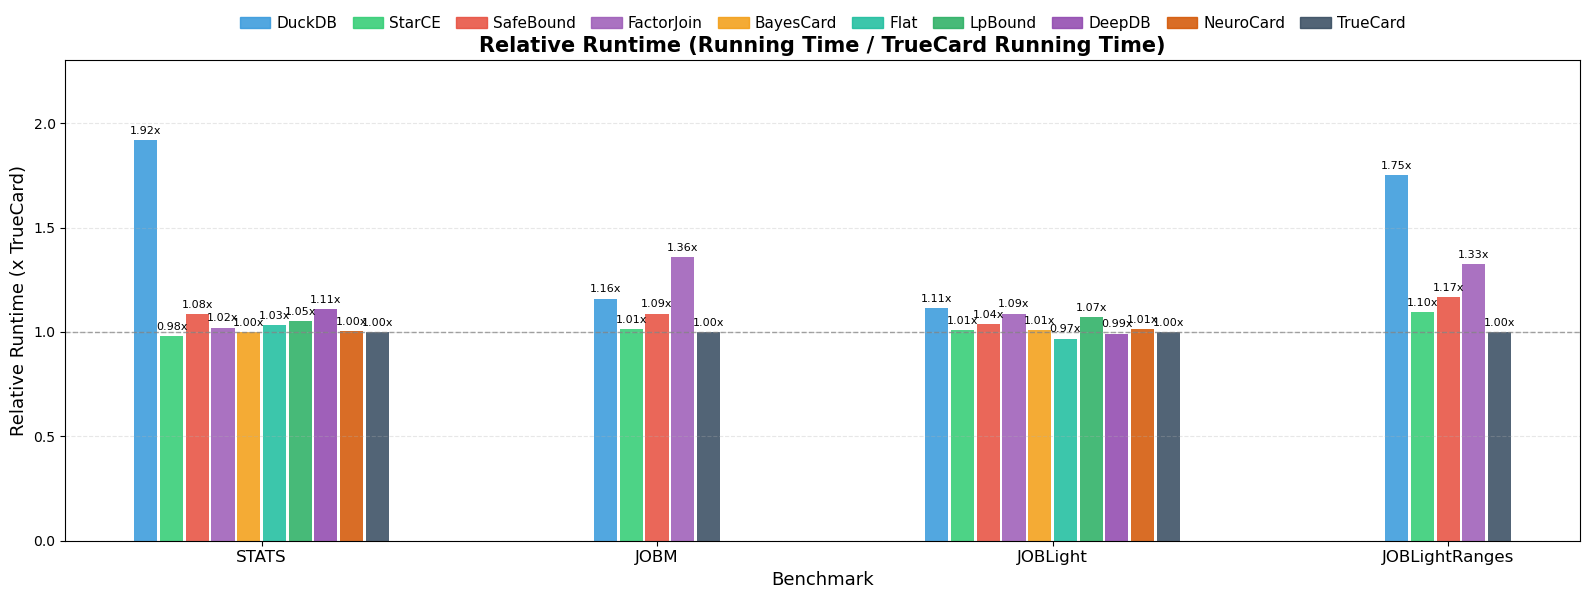

Relative runtime chart generated!


In [19]:
# ========== Plot: Relative Runtime Bar Chart ==========
# Show only running_time, converted to relative runtime (running_time / TrueCard running_time)
# All benchmarks in one chart; methods without data are not shown

methods_rel = ['DuckDB', 'StarCE', 'SafeBound', 'FactorJoin', 'BayesCard', 'Flat', 'LpBound', 'DeepDB', 'NeuroCard', 'TrueCard']
benchmarks_rel = ['STATS', 'JOBM', 'JOBLight', 'JOBLightRanges']

# Calculate relative runtime
relative_runtime = {}
for method in methods_rel:
    relative_runtime[method] = {}
    for benchmark in benchmarks_rel:
        method_rt = performance_results.get(method, {}).get(benchmark, {}).get('running_time')
        truecard_rt = performance_results.get('TrueCard', {}).get(benchmark, {}).get('running_time')
        if method_rt is not None and truecard_rt is not None and truecard_rt > 0:
            relative_runtime[method][benchmark] = method_rt / truecard_rt
        else:
            relative_runtime[method][benchmark] = None

# Find methods with data (at least one benchmark has a value)
active_methods = [m for m in methods_rel if any(relative_runtime[m][b] is not None for b in benchmarks_rel)]

fig_rel, ax_rel = plt.subplots(figsize=(16, 7))

bar_width = 0.065  # Uniform bar width
all_vals_for_ylim = []

for bi, benchmark in enumerate(benchmarks_rel):
    # Methods with data for this benchmark
    available = [(m, relative_runtime[m][benchmark]) for m in active_methods if relative_runtime[m][benchmark] is not None]
    if not available:
        continue
    n_avail = len(available)
    group_width = n_avail * bar_width
    base_x = bi

    for mi, (method, val) in enumerate(available):
        all_vals_for_ylim.append(val)
        offset = (mi - (n_avail - 1) / 2) * bar_width
        bar = ax_rel.bar(
            base_x + offset,
            val,
            bar_width * 0.9,
            color=colors[method],
            alpha=0.85,
        )
        ax_rel.annotate(
            f'{val:.2f}x',
            xy=(bar[0].get_x() + bar[0].get_width() / 2, val),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8, clip_on=False,
        )

# TrueCard baseline
ax_rel.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)

if all_vals_for_ylim:
    ax_rel.set_ylim(0, max(all_vals_for_ylim) * 1.2)

ax_rel.set_title('Relative Runtime (Running Time / TrueCard Running Time)', fontsize=15, fontweight='bold')
ax_rel.set_xlabel('Benchmark', fontsize=13)
ax_rel.set_ylabel('Relative Runtime (x TrueCard)', fontsize=13)
ax_rel.set_xticks(range(len(benchmarks_rel)))
ax_rel.set_xticklabels(benchmarks_rel, fontsize=12)
ax_rel.grid(axis='y', which='major', alpha=0.3, linestyle='--')

# Legend placed horizontally on top
legend_handles_rel = [plt.Rectangle((0, 0), 1, 1, color=colors[m], alpha=0.85) for m in active_methods]
ax_rel.legend(
    legend_handles_rel,
    active_methods,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=len(active_methods),
    frameon=False,
    fontsize=11,
    columnspacing=1.0,
    handletextpad=0.4,
)

plt.tight_layout(rect=[0, 0, 1, 0.88])

# Save PDF to checkpoint directory
_pdf_path_rel = _project_root / "experiment" / "checkpoint" / "EvaluatePerformance" / "relative_runtime.pdf"
fig_rel.savefig(_pdf_path_rel, bbox_inches='tight')
print(f"PDF saved to: {_pdf_path_rel}")

plt.show()
print('Relative runtime chart generated!')